Exploratory Data Analysis

In [1]:
#Importing necessary libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

#Loading the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Cleanup the Data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)



c:\Users\sujay\anaconda3\envs\python_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Filter for Data Analyst Roles in India

In [19]:
#applying filters to get data for Data Analyst jobs in India
df_DA_India = df[(df['job_title_short'] == 'Data Analyst') & (df['job_location'] == 'India')].copy()

In [73]:
#Filter for Job Title and Country
job_titles = 'Data Engineer'
job_country = 'United States'


In [74]:
df_Data_Jobs = df[(df['job_title_short'] == job_titles) & (df['job_country'] == job_country)]

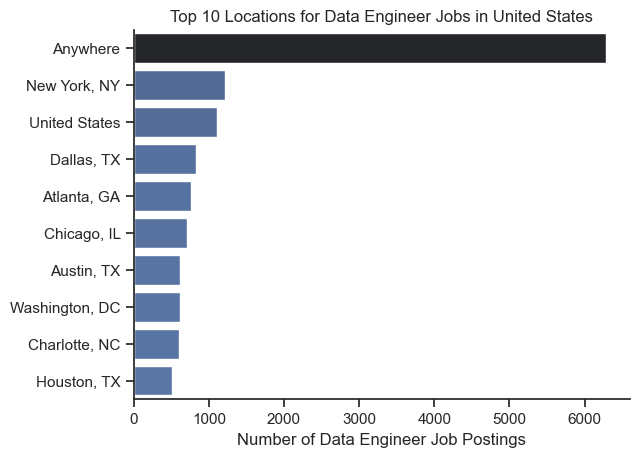

In [75]:
df_Plot = df_Data_Jobs['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style = 'ticks')
sns.barplot(data = df_Plot, x = 'count', y = 'job_location', hue = 'count', palette = 'dark:b_r', legend = False)
sns.despine()
plt.title(f'Top 10 Locations for {job_titles} Jobs in {job_country}')
plt.xlabel(f'Number of {job_titles} Job Postings')
plt.ylabel('')
plt.show()

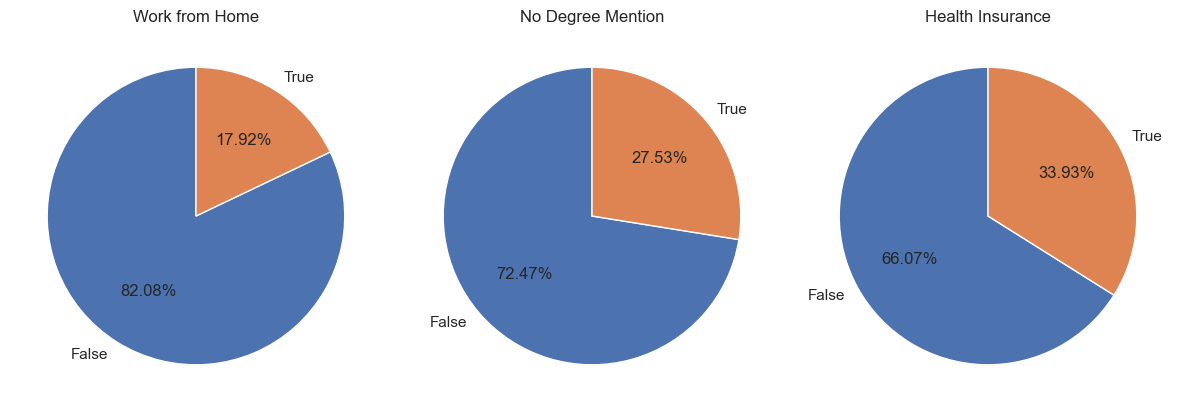

In [76]:
dict_column = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention': 'No Degree Mention',
    'job_health_insurance': 'Health Insurance'
}

fig, ax = plt.subplots(1, 3)
fig.set_size_inches(12, 5)

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_Data_Jobs[column].value_counts(), startangle = 90, autopct = '%1.2f%%', labels =['False', 'True'])
    ax[i].set_title(title)
plt.tight_layout()
plt.show()

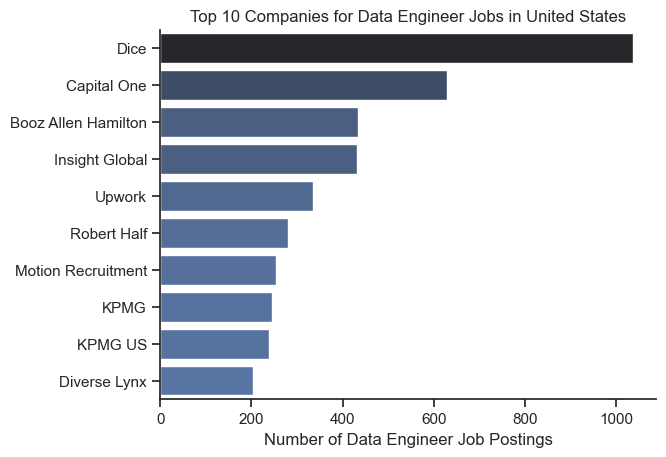

In [77]:
df_Plot = df_Data_Jobs['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style = 'ticks')
sns.barplot(data = df_Plot, x = 'count', y = 'company_name', hue = 'count', palette = 'dark:b_r', legend = False)
sns.despine()
plt.title(f'Top 10 Companies for {job_titles} Jobs in {job_country}')
plt.xlabel(f'Number of {job_titles} Job Postings')
plt.ylabel('')
plt.show()